In [2]:
cd vlm_muscle/

[Errno 2] No such file or directory: 'vlm_muscle/'
/home/cxy/Desktop/mpc2/vlm_muscle/utils


In [152]:
# folder = "/media/cxy/My Passport/logs/upperbody/handcube/20251111_035613"
# folder = "/media/cxy/My Passport/logs/fullbody/walking_flat/20250924_222500"
folder = "/media/cxy/My Passport/logs/fullbody/walking_flat/20251109_153933"
# folder = "/media/cxy/My Passport/logs/upperbody/handbottle/20251108_111426"
# folder = "/media/cxy/My Passport/logs/ostrich/walk_ostrich/20250925_042523"
# folder = "/media/cxy/My Passport/logs/fullbody/walking_flat/20251022_154714"

In [153]:
import os
import json
txt_file_path = os.path.join(folder, "compressed_weights.txt")
with open(txt_file_path, "r") as f:
    txt_content = f.read()
    weights = json.loads(txt_content)

    for k, v in weights.items():
        weights[k] = [x if x is not None else 0 for x in v]

In [161]:
import os
import json
import pandas as pd
import numpy as np

stage_dirs = [
    d for d in sorted(os.listdir(folder))
    if d.startswith("stage") and os.path.isdir(os.path.join(folder, d))
]

stage_agent_cost = {}
cost_terms = {}
cost_names = {}
for d in stage_dirs:
    # Only include stages from stage_15 to stage_25 (inclusive)
    if (d.startswith("stage_") and d[6:].isdigit() and 15 <= int(d[6:]) <= 25):
        continue
    if d not in "stage_0":
        csv_path = os.path.join(folder, d, "agent_cost_log.csv")
        cost     = os.path.join(folder, d, "cost_terms.json")
    else:
        csv_path = os.path.join(folder, d, "agent_cost_log.csv")
        cost     = os.path.join(folder, d, "cost_terms.json")
    if not os.path.isfile(csv_path):
        print(f"Skipping {d}: agent_cost_log.csv not found")
        continue

    df = pd.read_csv(csv_path)
    costs = json.load(open(cost, 'r'))
    # remove first and second columns (indices 0 and 1) if they exist
    if df.shape[1] >= 2:
        df = df.drop(df.columns[1], axis=1)
        
    stage_agent_cost[d] = df.to_numpy()
    cost_names[d] = [name.replace('_', ' ') for name in costs.keys()]
    cost_terms[d] = list(costs.values())
# stage_agent_cost is a dict mapping stage folder -> numpy array (with second column removed)
print({k: v.shape for k, v in stage_agent_cost.items()})
print(cost_names)
print(cost_terms)

{'stage_0': (13558, 4), 'stage_1': (40295, 9), 'stage_10': (16749, 14), 'stage_11': (14793, 15), 'stage_12': (16479, 15), 'stage_13': (15208, 15), 'stage_14': (14798, 16), 'stage_2': (26385, 9), 'stage_3': (38061, 10), 'stage_4': (36617, 10), 'stage_5': (22872, 11), 'stage_6': (43355, 11), 'stage_7': (14876, 12), 'stage_8': (15297, 12), 'stage_9': (10467, 13)}
{'stage_0': ['Height', 'Balance', 'Joint pos'], 'stage_1': ['Height', 'Balance', 'Joint pos', 'Forward Velocity', 'Directional Stability', 'Posture', 'Foot Contact', 'Arm Swing Coordination'], 'stage_10': ['Height', 'Balance', 'Joint pos', 'Forward Velocity', 'Directional Stability', 'Posture', 'Torso Orientation', 'Foot Contact', 'Arm Swing Coordination', 'Straight Path', 'Core Strength Control', 'Knee Bend', 'Foot Placement'], 'stage_11': ['Height', 'Balance', 'Joint pos', 'Forward Velocity', 'Directional Stability', 'Posture', 'Torso Orientation', 'Foot Contact', 'Arm Swing Coordination', 'Straight Path', 'Core Strength Contro

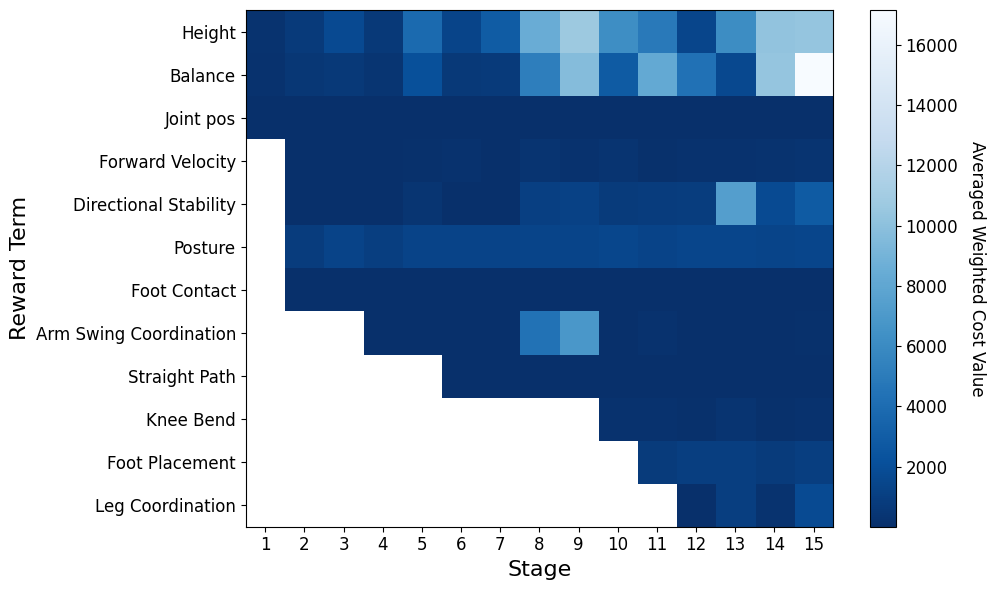

In [163]:
import matplotlib.pyplot as plt

# Collect all stages in sorted order
stages = sorted(stage_agent_cost.keys(), key=lambda x: int(x.split('_')[1]))
avg_costs_per_stage = []
cost_term_labels = []

for stage in stages:
    values = stage_agent_cost[stage]
    names = cost_names[stage]
    terms = cost_terms[stage]
    # Exclude the first column (time)
    data = values[:, 1:] * np.array(terms)
    # Average each cost term over time (axis 0)
    avg_costs = data.mean(axis=0)
    avg_costs_per_stage.append(avg_costs)
    cost_term_labels.append(names)

# Find the maximum number of cost terms across all stages
max_terms = max(len(x) for x in avg_costs_per_stage)

# Pad with NaN for plotting if some stages have fewer terms
avg_costs_per_stage_padded = [
    np.pad(x, (0, max_terms - len(x)), constant_values=np.nan)
    for x in avg_costs_per_stage
]

# Use the cost term labels from the last stage for y-axis
y_labels = cost_term_labels[-1]

avg_costs_arr = np.array(avg_costs_per_stage_padded).T  # shape: (num_terms, num_stages)
stages=[f"{i}" for i in range(1, len(stages)+1)]

plt.figure(figsize=(10, 6))
im = plt.imshow(avg_costs_arr[np.array([i for i in range(avg_costs_arr.shape[0]) if i not in [6, 10, 14]])], aspect='auto', interpolation='nearest', cmap='Blues_r')
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Averaged Weighted Cost Value', fontsize=12, rotation=-90, labelpad=20)
plt.yticks(np.arange(len(y_labels)-3), [label for i, label in enumerate(y_labels) if i not in [6, 10, 14]], fontsize=12)
plt.xticks(np.arange(len(stages)), stages, fontsize=12)
plt.xlabel('Stage', fontsize=16)
plt.ylabel('Reward Term', fontsize=16)
# plt.title('Bottle Pouring Weighted Cost Terms per Stage')
plt.tight_layout()
plt.show()

In [156]:
# Log normalize avg_costs_arr (add small epsilon to avoid log(0))
epsilon = 1e-8
avg_costs_arr = np.log(avg_costs_arr + epsilon)

In [13]:
weights = {label.replace('_', ' '): avg_costs_arr[i] for i, label in enumerate(y_labels)}
for k, v in weights.items():
    weights[k] = [0 if (x is None or (isinstance(x, float) and np.isnan(x))) else x for x in v]


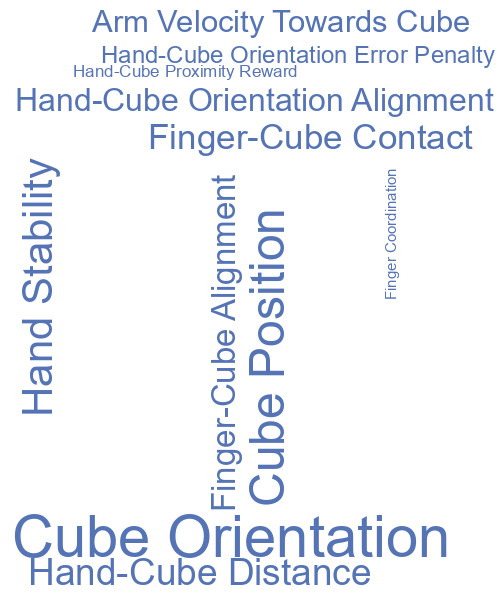

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import pandas as pd
import numpy as np
import os

exclude_terms = {"Height", "Balance"}
custom_stopwords = STOPWORDS.union(exclude_terms)

# Compute overall weight importance
term_strength = {term: sum(vals) for term, vals in weights.items()}  # total weight per term
sorted_terms = dict(sorted(term_strength.items(), key=lambda x: x[1], reverse=True))

# Convert to DataFrame for Seaborn heatmap ===
df = pd.DataFrame(weights)
df.index = [f"Stage {i+1}" for i in range(len(next(iter(weights.values()))))]

color_func=lambda *args, **kwargs: "rgb(85, 116, 182)"

import matplotlib.font_manager as fm

# Try to find Helvetica on the system
helvetica_path = '/home/cxy/.local/share/fonts/ARIAL.TTF'

wordcloud = WordCloud(
   width=500,
   height=600,
   background_color="white",
   color_func=color_func,
   stopwords=custom_stopwords,
   prefer_horizontal=0.8,
   max_words=100,
   font_path=helvetica_path,  # fallback if Helvetica not available
).generate_from_frequencies(term_strength)

wordcloud.to_image()
